<a href="https://colab.research.google.com/github/antas06/DL_Scratch/blob/Root_functions/cc_fr_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

print("MNIST dataset loaded and preprocessed.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MNIST dataset loaded and preprocessed.


In [ ]:

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(test_images, test_labels))

print("Model trained.")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 32ms/step - accuracy: 0.9558 - loss: 0.1434 - val_accuracy: 0.9865 - val_loss: 0.0417
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.9859 - loss: 0.0451 - val_accuracy: 0.9883 - val_loss: 0.0346
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 32ms/step - accuracy: 0.9899 - loss: 0.0326 - val_accuracy: 0.9905 - val_loss: 0.0325
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9916 - loss: 0.0260 - val_accuracy: 0.9900 - val_loss: 0.0323
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9938 - loss: 0.0187 - val_accuracy: 0.9899 - val_loss: 0.0363
Model trained.


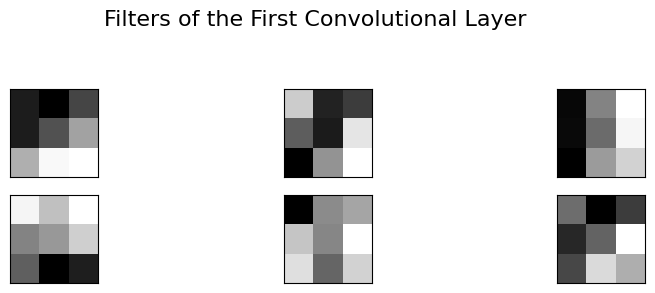

In [ ]:

filters, biases = model.layers[0].get_weights()


f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)


n_filters, ix = 6, 1
plt.figure(figsize=(10, 8))
for i in range(n_filters):

    f = filters[:, :, :, i]

    for j in range(1):

        ax = plt.subplot(n_filters, 3, ix)
        ax.set_xticks([])
        ax.set_yticks([])

        plt.imshow(f[:, :, j], cmap='gray')
        ix += 1
plt.suptitle('Filters of the First Convolutional Layer', fontsize=16)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


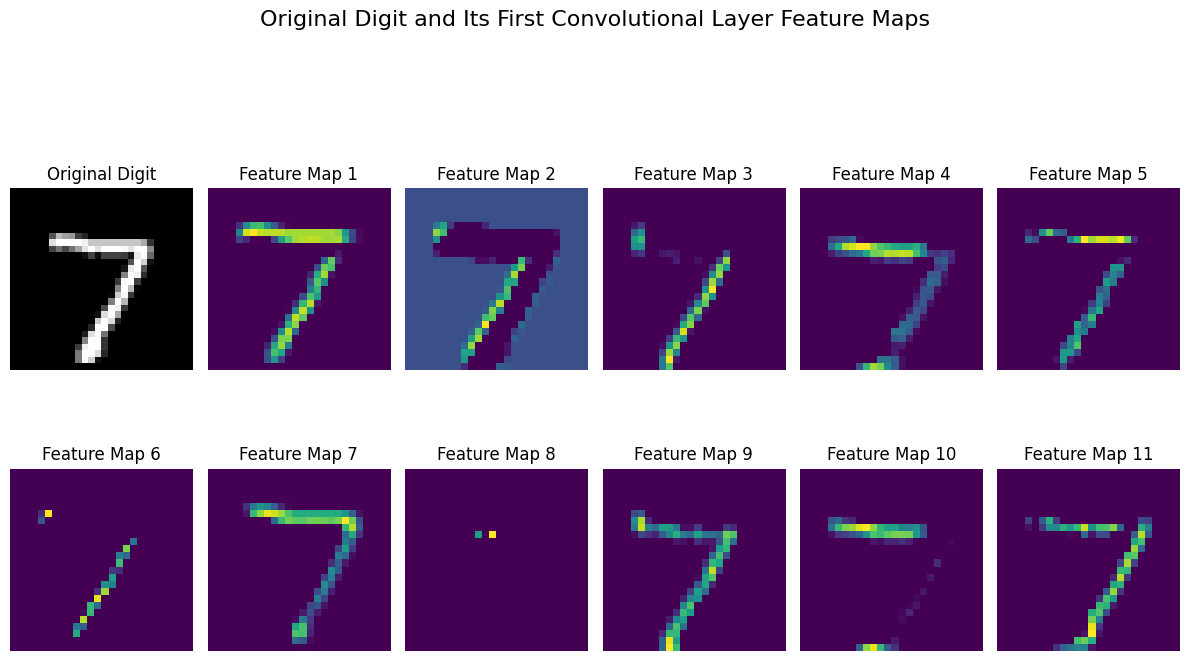

In [ ]:

sample_image = test_images[0]

feature_map_model = models.Model(inputs=model.inputs, outputs=model.layers[0].output)

feature_maps = feature_map_model.predict(np.expand_dims(sample_image, axis=0))

plt.figure(figsize=(12, 8))
plt.subplot(2, 6, 1)
plt.imshow(sample_image[:, :, 0], cmap='gray')
plt.title('Original Digit')
plt.axis('off')

n_feature_maps = feature_maps.shape[-1]
for i in range(min(n_feature_maps, 11)):
    ax = plt.subplot(2, 6, i + 2)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.title(f'Feature Map {i+1}')
    plt.axis('off')
plt.suptitle('Original Digit and Its First Convolutional Layer Feature Maps', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()